In [273]:
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import dilation, erosion, opening, closing
from skimage.morphology import footprint_rectangle
import numpy as np
from scipy.ndimage import morphological_gradient


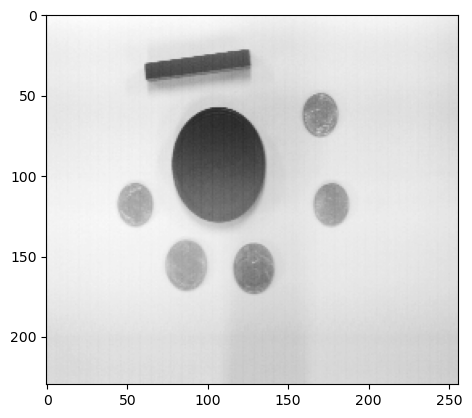

In [274]:
morpho = cv2.imread("images/MORPHO.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(morpho, cmap="gray")
plt.show()

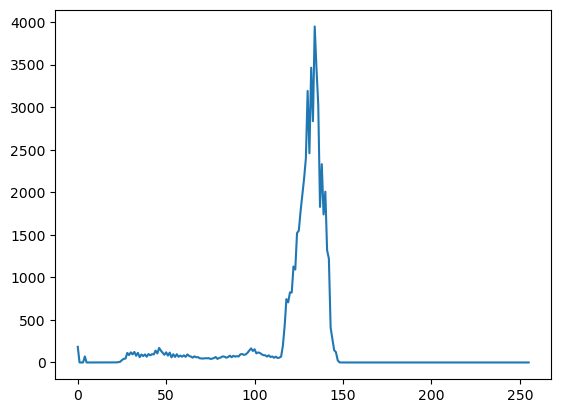

In [275]:
hist = cv2.calcHist([morpho], [0], None, [256], [0, 256])
plt.plot(hist)

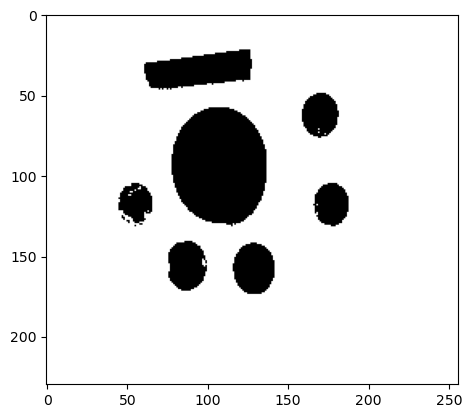

In [276]:

thres_value, thres_image = cv2.threshold(morpho, 110, 115, cv2.THRESH_BINARY)

plt.imshow(thres_image, cmap="gray")
plt.show()

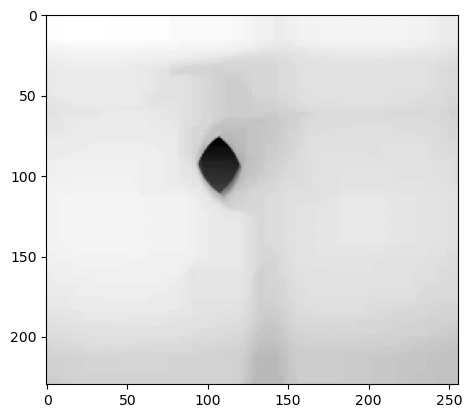

In [277]:
dilated_morpho = dilation(morpho, footprint=footprint_rectangle((29,29)))

plt.imshow(dilated_morpho, cmap="gray")
plt.show()


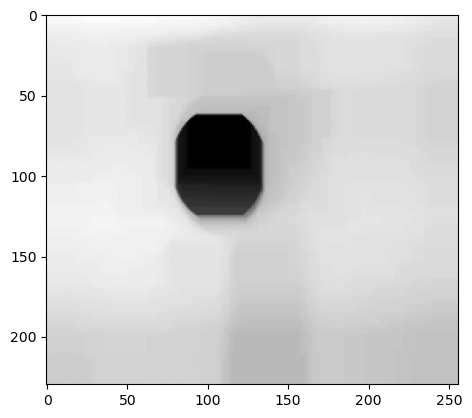

In [278]:
eroded_morpho_dilated = erosion(dilated_morpho, footprint=footprint_rectangle((29,29)))
plt.imshow(eroded_morpho_dilated, cmap="gray")
plt.show()

In [279]:

n = 11
kernel = np.empty((n, n), dtype=object) 
kernel[:] = None

c = n // 2
kernel[c, :] = 1
kernel[:, c] = 1

print(kernel)

[[None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [1 1 1 1 1 1 1 1 1 1 1]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]
 [None None None None None 1 None None None None None]]


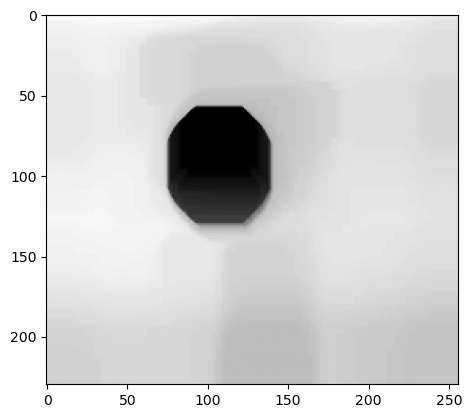

In [280]:
eroded_morpho_dilated2 = erosion(eroded_morpho_dilated, footprint=kernel)
plt.imshow(eroded_morpho_dilated2, cmap="gray")
plt.show()

In [281]:
print(np.max(eroded_morpho_dilated2))
print(np.max(thres_image))

146
115


### Sobre la original

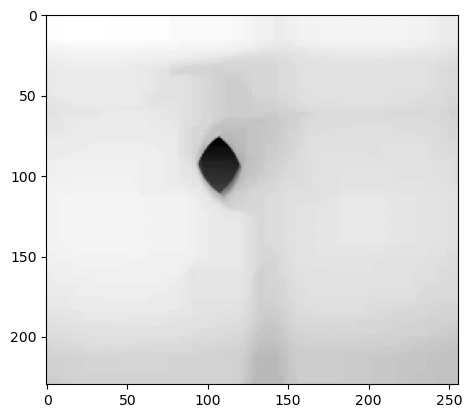

In [282]:
morpho_dilatado = dilation(morpho, footprint=footprint_rectangle((29,29)))
plt.imshow(morpho_dilatado, cmap="gray")
plt.show()

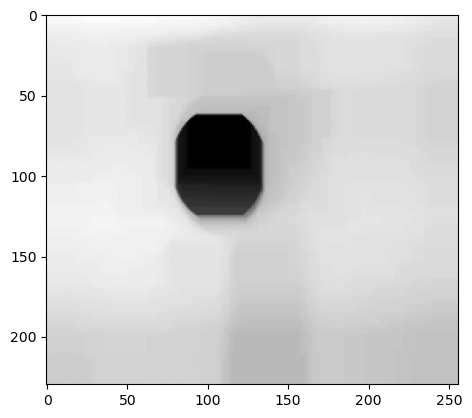

In [283]:
morphodilatado_erodado = erosion(morpho_dilatado, footprint=footprint_rectangle((29,29)))
plt.imshow(morphodilatado_erodado, cmap="gray")
plt.show()

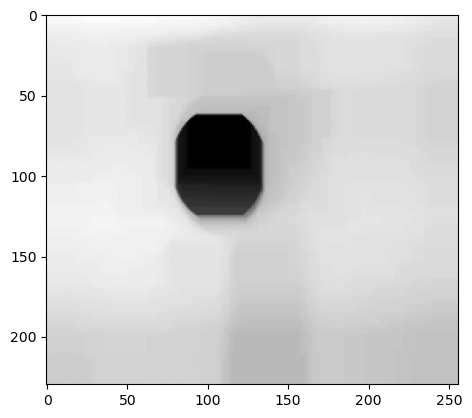

In [284]:
eroded_morpho_dilated2 = erosion(morphodilatado_erodado, footprint=kernel)
plt.imshow(morphodilatado_erodado, cmap="gray")
plt.show()

In [285]:
print(np.max(eroded_morpho_dilated2))

146


# Gradiente morfológico

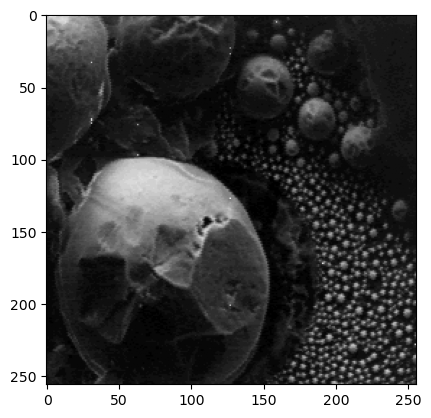

In [286]:
meb = cv2.imread("images/MEB.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(meb, cmap="gray")
plt.show()

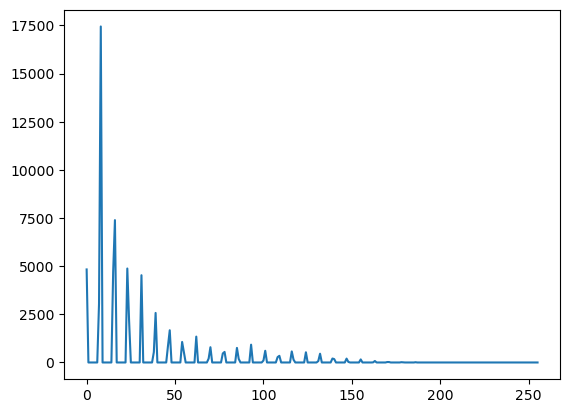

In [287]:
mgimage = morphological_gradient(meb, size=((3,3)))
hist1 = cv2.calcHist([mgimage], [0], None, [256], [0, 256])
plt.plot(hist1)

from skimage import exposure


rescaled_img = exposure.rescale_intensity(mgimage, in_range=(0,100), out_range=(0,255))



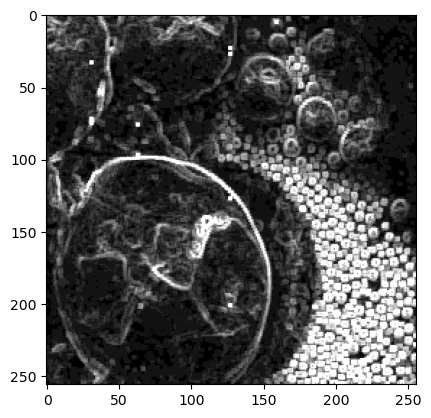

In [288]:

plt.imshow(rescaled_img, cmap="gray")
plt.show()

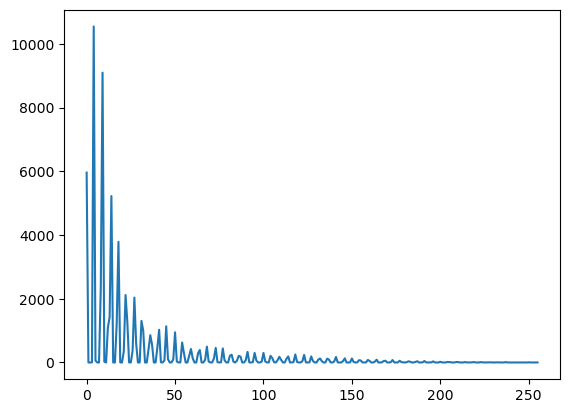

In [289]:

from skimage.filters import sobel_h, sobel_v, sobel

#Aplica el filtro Sobel horizontal
img_sh = sobel_h(meb)
#Aplica el filtro Sobel vertical
img_sv = sobel_v(meb)
#Calcula bordes usando el filtro de sobel
final = np.abs(img_sh) + np.abs(img_sv)
final = (final / np.max(final) * 255).astype(np.uint8)
hist2c = cv2.calcHist([final], [0], None, [256], [0, 256])
plt.plot(hist2c)

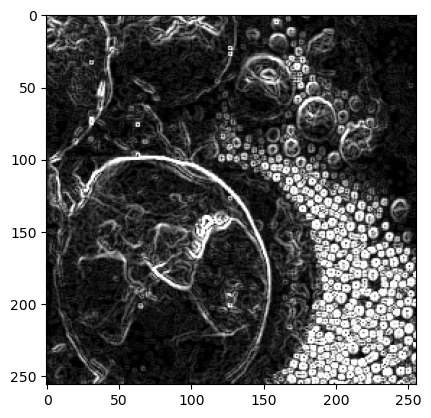

In [290]:
img_escalada = exposure.rescale_intensity(final, in_range=(0,100), out_range=(0,255))

plt.imshow(img_escalada, cmap="gray")
plt.show()

# Operadores de apertura y cierre

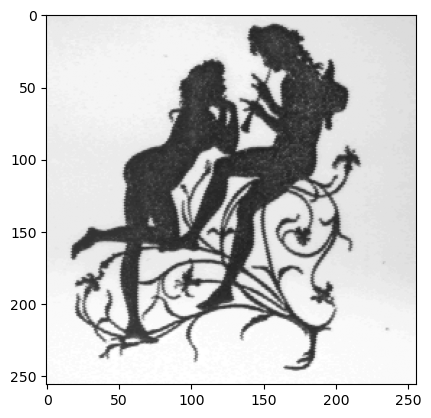

In [291]:
amour = cv2.imread("images/AMOUR.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(amour, cmap="gray")
plt.show()

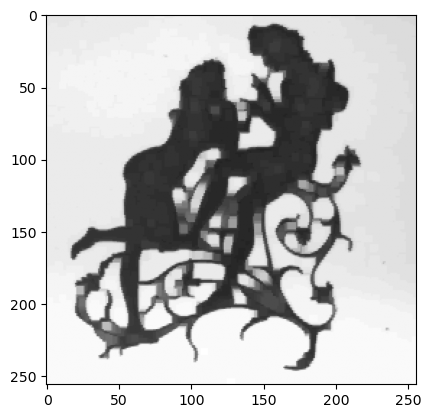

In [292]:
opening_image = opening(amour, footprint=footprint_rectangle((5,5)))
plt.imshow(opening_image, cmap="gray")
plt.show()

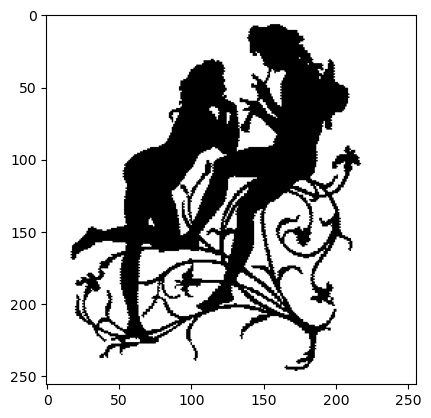

In [293]:
amour_umbralizada = cv2.threshold(amour, 30, 35, cv2.THRESH_BINARY)[1]
plt.imshow(amour_umbralizada, cmap="gray")
plt.show()


In [294]:
n = 3
kernelDiagDer = np.empty((n,n), dtype=object)
kernelDiagDer[:] = None

for i in range(n):
    for j in range(n):
        if i == j:
            kernelDiagDer[i,j] = 1
print(kernelDiagDer)

[[1 None None]
 [None 1 None]
 [None None 1]]


In [295]:
n = 3
kernelDiagIzq = np.empty((n,n), dtype=object)
kernelDiagIzq[:] = None

offset = n-1
for i in range(n):
    for j in range(n):
        if i + j == offset:
            kernelDiagIzq[i, j] = 1
print(kernelDiagIzq)

[[None None 1]
 [None 1 None]
 [1 None None]]


In [296]:
kernelHor = np.ones((1,3), dtype = object)
print(kernelHor)

[[1 1 1]]


In [297]:
kernelVert = np.ones((3,1), dtype = object)
print(kernelVert)

[[1]
 [1]
 [1]]


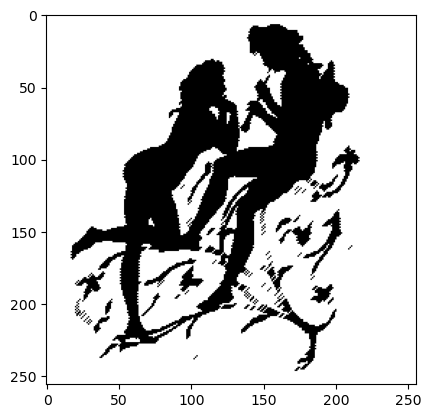

In [298]:
final = closing(amour_umbralizada, kernelDiagIzq)
plt.imshow(final, cmap="gray")
plt.show()

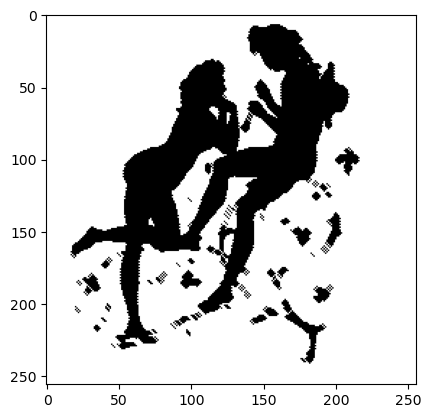

In [299]:
final = closing(final, kernelDiagDer)
plt.imshow(final, cmap="gray")
plt.show()

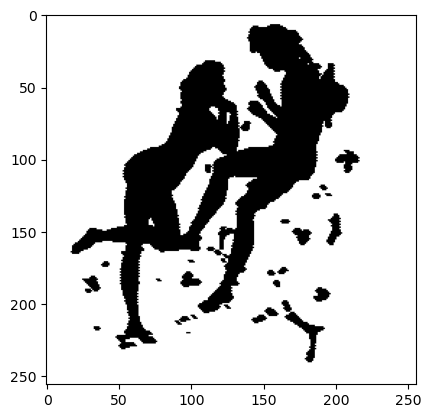

In [300]:
final = closing(final, kernelHor)
plt.imshow(final, cmap="gray")
plt.show()

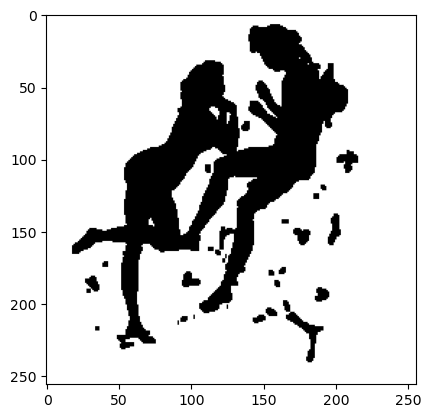

In [301]:
final = closing(final, kernelVert)
plt.imshow(final, cmap="gray")
plt.show()

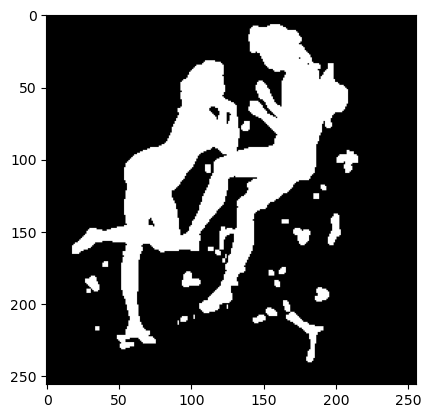

In [302]:
neg = cv2.bitwise_not(final)
plt.imshow(neg, cmap="gray")
plt.show()

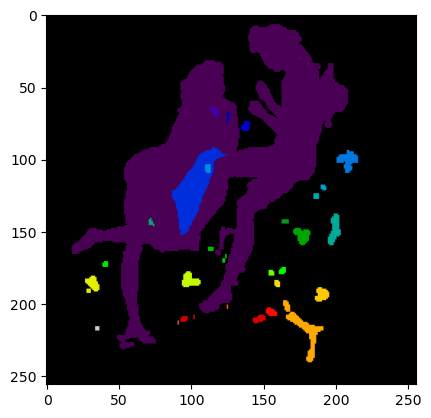

In [303]:
from skimage.measure import label

connected_components = label(neg, background=0, connectivity=2)
plt.imshow(connected_components, cmap="nipy_spectral")
plt.show()

# Etiquetado de objetos


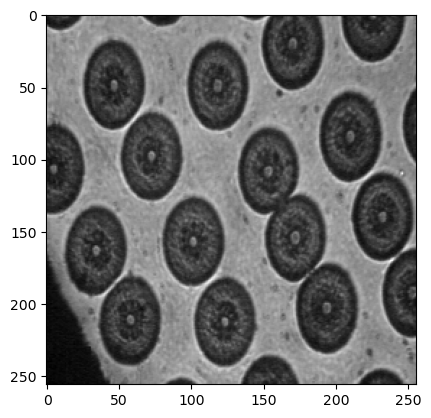

In [304]:
sic = cv2.imread("images/SIC.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(sic, cmap="gray")
plt.show()

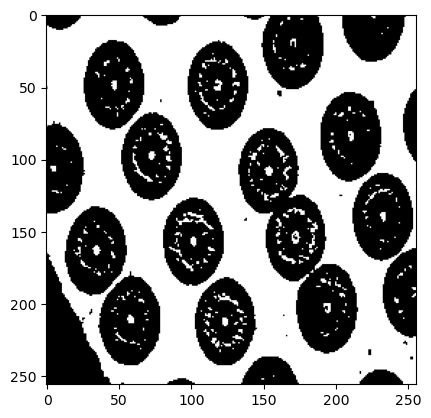

In [342]:
import cv2

thres_value, thres_image = cv2.threshold(sic, 55, 75, cv2.THRESH_BINARY)
plt.imshow(thres_image, cmap="gray")
plt.show()

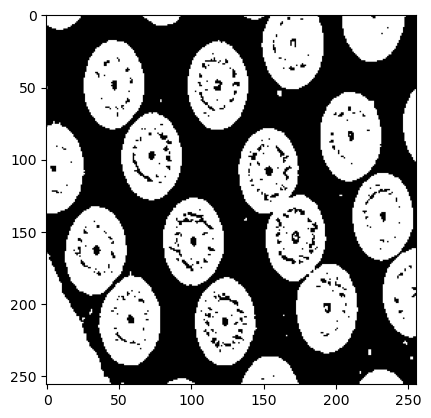

In [347]:
neg = cv2.bitwise_not(thres_image)
plt.imshow(neg, cmap="gray")
plt.show()

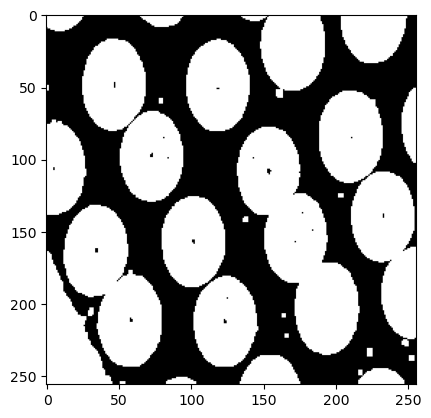

In [348]:
sic_dilatado = dilation(neg, footprint=footprint_rectangle((3,3)))
plt.imshow(sic_dilatado, cmap="gray")
plt.show()

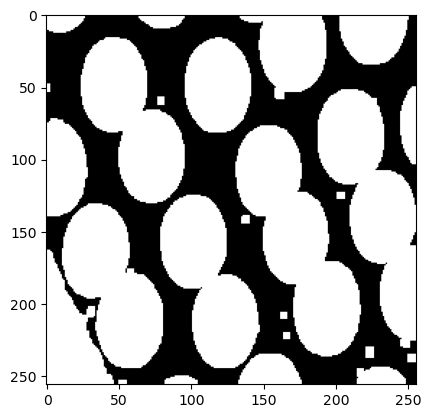

In [349]:
sic_dilatado = dilation(sic_dilatado, footprint=footprint_rectangle((3,3)))
plt.imshow(sic_dilatado, cmap="gray")
plt.show()

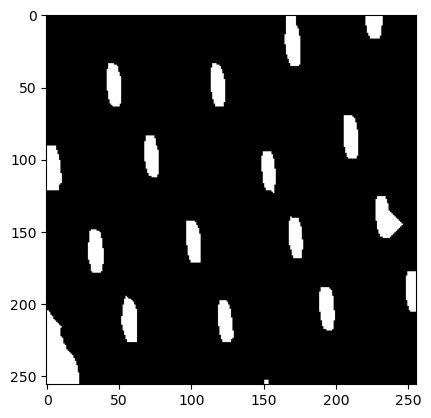

In [350]:
slic_izq = erosion(sic_dilatado, footprint=kernelDiagIzq)
for i in range(10):
    slic_izq = erosion(slic_izq, footprint=kernelDiagIzq)

slic_der = erosion(slic_izq, footprint=kernelDiagDer)
for i in range(6):
    slic_der = erosion(slic_der, footprint=kernelDiagDer)
    
plt.imshow(slic_der, cmap="gray")
plt.show()

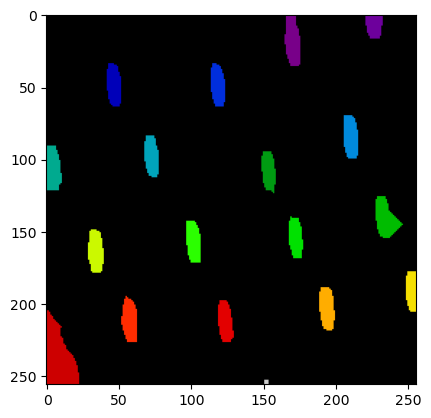

In [351]:
from skimage.measure import label

connected_components = label(slic_der, background=0, connectivity=2)
plt.imshow(connected_components, cmap="nipy_spectral")
plt.show()